In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
from pygam import LogisticGAM, s
import matplotlib.cm as cm
from scipy.linalg import sqrtm

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal,f
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)

def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def create_indicator_diagonal_matrix(index_list, n):
    diag = np.zeros(n)
    diag[index_list] = 1
    return np.diag(diag), diag

def apply_whitening( X,Sigma):
    """If sigma is a matrix, whiten X = Sigma^{-1/2} X."""
    from scipy.linalg import sqrtm
    Sigma = np.asarray(Sigma, dtype=float)   # <-- clean conversion
    Sigma_inv_sqrt = np.linalg.inv(sqrtm(Sigma))
    return X @ Sigma_inv_sqrt
def naive_p_value(X, node, sigma, grid_width=25, ngrid=1000):
    X = apply_whitening(X, sigma)
    from scipy.stats import chi
    n = np.shape(X)[0]
    p = np.shape(X)[1]
    nu = compute_nu(node, n).reshape(-1, 1)
    # obs_target = np.linalg.norm(X.T@nu)/(np.linalg.norm(nu)*sigma)
    # Extract cluster indices
    left_indices = node.left.points
    right_indices = node.right.points

    # Compute cluster means
    left_mean = np.mean(X[left_indices, :], axis=0)
    right_mean = np.mean(X[right_indices, :], axis=0)

    # Compute the Euclidean distance between cluster means
    obs_target = np.linalg.norm(left_mean - right_mean)

    # Compute the scaling factor
    n_left = len(left_indices)
    n_right = len(right_indices)
    scale_factor = sigma * np.sqrt(1 / n_left + 1 / n_right)
    p_value = 1 - chi.cdf(obs_target / scale_factor, df=p)
    return p_value

def generate_null_data(n, p, mu=None, sigma=1.0):
    if mu is None:
        mu = np.zeros(p)
    mu = np.asarray(mu)

    # handle sigma
    if np.isscalar(sigma):
        Sigma = (sigma ** 2) * np.eye(p)
    else:
        Sigma = np.asarray(sigma)
        if Sigma.shape != (p, p):
            raise ValueError(f"Covariance matrix must be {p}×{p}, got {Sigma.shape}.")

    if mu.shape[0] != p:
        raise ValueError(f"Mean vector length {mu.shape[0]} does not match p={p}.")

    X = np.random.multivariate_normal(mean=mu, cov=Sigma, size=n)
    return X
def _apply_whitening(X,Sigma):
    """If sigma is a matrix, whiten X =  X Sigma^{-1/2}."""
    Sigma = np.asarray(Sigma, dtype=float)
    Sigma_inv_sqrt = np.linalg.inv(sqrtm(Sigma))
    return X @ Sigma_inv_sqrt
def check_p_value_uniformity(n, p, sigma, K, tau, linkage="complete", num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)

    while len(p_values) < num_trials:
        X = generate_null_data(n, p, mu, sigma)
        model = AgglomerativeClustering(X, sigma, tau=tau, n_clusters=K, linkage=linkage)
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[-1]
        node = key[0].parent

        p_value, obs, sel = model.merge_inference_chi(node, grid_width=50, ncoarse=20, ngrid=2000, Sigma = sigma)
        #p_value_n = naive_p_value(X, node,sigma,linkage)
        #if not (np.isnan(p_value) and np.isnan(p_value_n)):
        if not (np.isnan(p_value)):
            p_values.append(p_value)
    p_values = np.array(p_values)
    #p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="Selection-based p-value")
    #plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    #sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    #sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
             label="Selection-based p-values")
    #plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


In [3]:
n, p = 30, 3
mu = [0, 0, 0]
sigma = np.array([
    [1.0, 0.3, 0.6],
    [0.3, 2.0, 0.2],
    [0.6, 0.2, 2.0]
])
tau=0.1
K=3
linkage = "complete"
X = generate_null_data(n, p, mu, sigma)
model = AgglomerativeClustering(X,sigma, tau=tau, n_clusters=K, linkage=linkage)
model.fit()

winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent

p_value, obs, sel = model.merge_inference_chi(node, grid_width=20, ncoarse=20, ngrid=2000, Sigma = sigma)

1e-05 11.211654900056086


0.630991745976111 5.75754026396875
1e-05 9.065155958958204
3.0257103743392264 8.522170299808117
0.2751747717419737 5.599904177853384
0.138622101330808 5.5724832446915595
0.28350965851505894 7.779787123532435
1e-05 9.098771768715608
0.5834618200995334 6.085001741982259
1e-05 5.463860020123482
0.4213014858040225 6.533102849309692
1e-05 5.975310913847456
0.5585869576772047 6.492098883682728
0.4946685373980757 5.790448681557018
0.923581517678473 6.317047602804017
0.46873412109742585 6.613348132795926
0.5270339355873519 5.831821885534911
0.9297060577195375 5.673848334656277
0.025153419330856686 6.350120392003955
1e-05 5.9635352574673846
1.0693356608175866 5.763125292018947
0.2860242446456267 7.652315972400189
0.5683244342557079 5.947867749826816
0.617820876354267 4.991454305022396
0.33992031183006866 6.041144569444502
1e-05 9.524788471603806
0.5295483049975065 5.764167982561405
1e-05 8.01471333914144
0.7828004769279526 5.307359508687812
1.8302559532362181 9.226136313887977
1.821202853898316

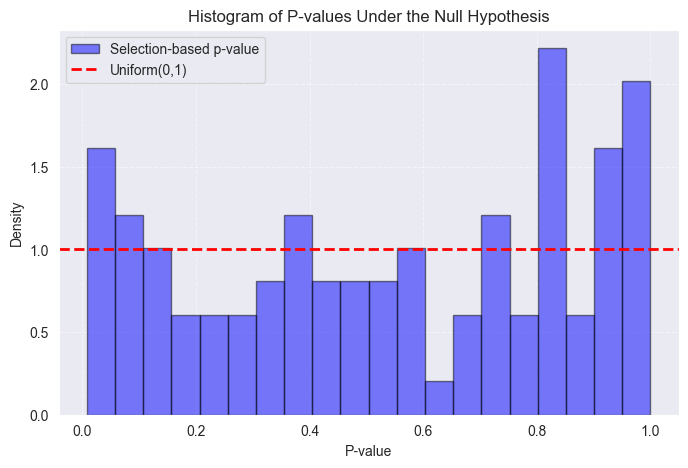

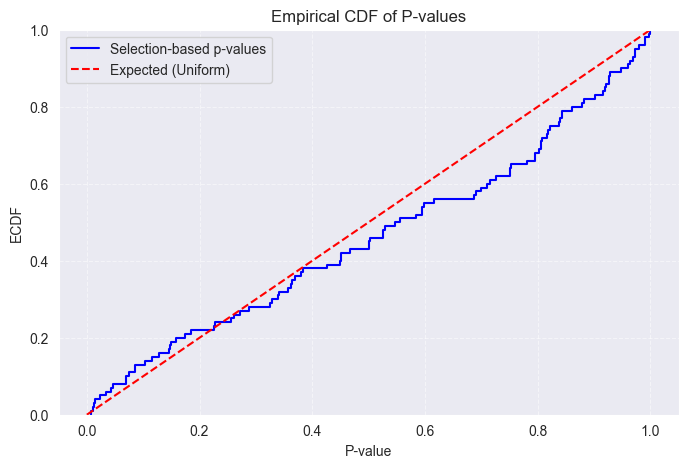

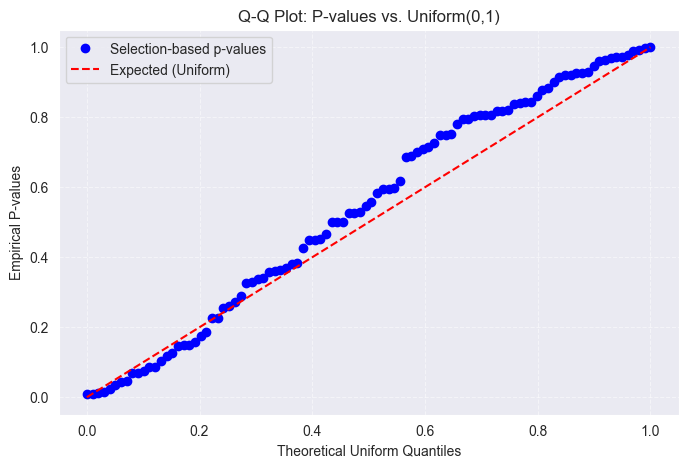

In [4]:
check_p_value_uniformity(n, p, sigma, K, 0.01, linkage="minimax", num_trials=100)

In [ ]:
X, y = make_blobs(n_samples=30, centers=3, cluster_std=1, random_state= 0)
model = AgglomerativeClustering(X, tau=0.1, n_clusters=2,linkage="complete", random_state= 0)
model.fit()
c1,c2 = model.K_clusters
pval,_,_ = model.merge_inference_F_random_pair(c1,c2)

In [ ]:
pval

In [ ]:
from utils import check_p_value_uniformity, generate_null_data

In [ ]:
check_p_value_uniformity(30, 10, 1, 3, 0.1, -1, linkage="complete", num_trials=100)

In [ ]:
generate_null_data(30,2)

In [ ]:
result = pd.read_csv("/Users/judydw/Downloads/k_hat_results.csv")

In [8]:
result.groupby('delta')['Preserve'].mean()

NameError: name 'result' is not defined

In [9]:
(result.groupby("delta").apply(lambda g: pd.Series({
    "P(K<=3, Preserve=True| Preserve=True)": ((g["K_hat_F"] <= 3) & (g["Preserve"])).sum() / (g["Preserve"]).sum()
    if (g["Preserve"]).sum() > 0 else float("nan"),
    "P(K<=3，Preserve= False | Preserve=False)": ((g["K_hat_F"] <= 3) & (~g["Preserve"])).sum() / (~g["Preserve"]).sum()
    if (~g["Preserve"]).sum() > 0 else float("nan"),
    "P(Preserve = False)": (~g["Preserve"]).sum() / ((~g["Preserve"]).sum() +  (g["Preserve"]).sum()),
    
})).reset_index())

NameError: name 'result' is not defined

In [10]:
dfg = pd.read_csv("/Users/judydw/Downloads/rejection_and_effect_gao.csv")
dfgc = pd.read_csv("/Users/judydw/Downloads/rejection_and_effect_gao_clustered.csv")
dfb = pd.read_csv("/Users/judydw/Downloads/rejection_and_effect_barber.csv")
dfr = pd.read_csv("/Users/judydw/Downloads/reject_es.csv")

Fitting tau=0.0


/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/pygam/pygam.py:1149: RuntimeWarning: divide by zero encountered in scalar divide
  r2["explained_deviance"] = 1.0 - full_d.sum() / null_d.sum()
/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/pygam/pygam.py:1150: RuntimeWarning: divide by zero encountered in scalar divide
  r2["McFadden"] = full_ll / null_ll
/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/pygam/pygam.py:1151: RuntimeWarning: divide by zero encountered in scalar divide
  r2["McFadden_adj"] = 1.0 - (full_ll - self.statistics_["edof"]) / null_ll


Fitting tau=0.01
Fitting tau=0.05
Fitting tau=0.1


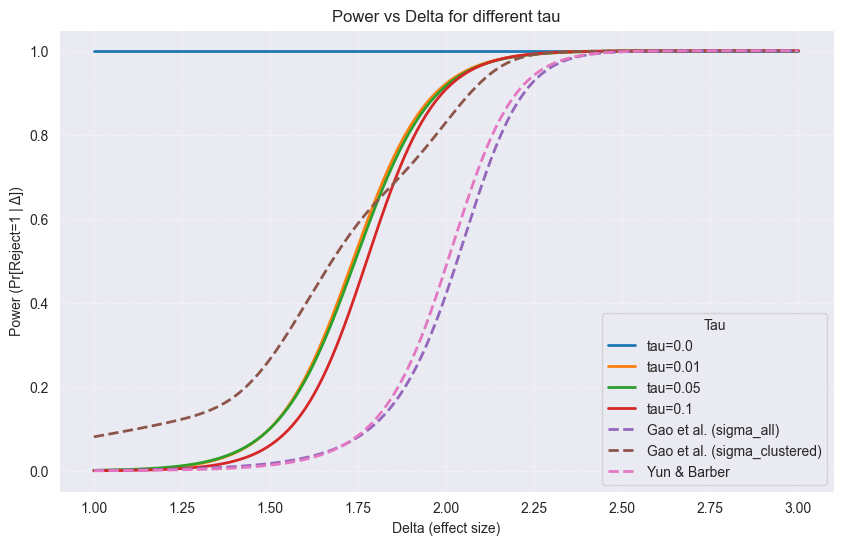

In [11]:
plt.figure(figsize=(10, 6))

for tau, g in dfr.groupby("tau"):
    X = g[["effect_size"]].values
    y = g["reject"].values


    print(f"Fitting tau={tau}")
    gam = LogisticGAM(s(0), n_splines=5, constraints='monotonic_inc').fit(X, y)
    grid = np.linspace(1.0, 3.0, 500)
    power_hat = gam.predict_mu(grid)
    plt.plot(grid, power_hat, lw=2, label=f"tau={tau}")
    
X_g = dfg["effect_size"].values
y_g = dfg["reject"].values
gam = LogisticGAM(s(0), n_splines=5, constraints='monotonic_inc').fit(X_g, y_g)
grid = np.linspace(1.0, 3.0, 500)
power_hat = gam.predict_mu(grid)
plt.plot(grid, power_hat, lw=2,linestyle='--', label="Gao et al. (sigma_all)")

    
X_gc = dfgc["effect_size"].values
y_gc = dfgc["reject"].values
gam = LogisticGAM(s(0), n_splines=15, constraints='monotonic_inc').fit(X_gc, y_gc)
grid = np.linspace(1.0, 3.0, 500)
power_hat = gam.predict_mu(grid)
plt.plot(grid, power_hat, lw=2,linestyle='--', label="Gao et al. (sigma_clustered)")

X_b = dfb["effect_size"].values
y_b = dfb["reject"].values
gam = LogisticGAM(s(0),  n_splines=5,constraints='monotonic_inc').fit(X_b, y_b)
grid = np.linspace(1.0, 3.0, 500)
power_hat = gam.predict_mu(grid)
plt.plot(grid, power_hat, lw=2,linestyle='--', label="Yun & Barber")
plt.xlabel("Delta (effect size)")
plt.ylabel("Power (Pr[Reject=1 | Δ])")
plt.title("Power vs Delta for different tau")
plt.legend(title="Tau")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [12]:
df = pd.read_csv("/Users/judydw/Downloads/hist_counts_combined_equal_False.csv")

In [13]:
result_dict = {}
df = df.drop(df.index[-1])
df = df.astype(int)
f = df.apply(pd.to_numeric, errors='coerce')
result_dict = {}
for column in df.columns:
    non_zero_data = df[column][df[column] != 0].astype(str)
    
    sorted_non_zero_data = dict(sorted(non_zero_data.items(), key=lambda item: int(item[1]), reverse=True))
    
    # 将排序后的结果存储为字典
    result_dict[column] = sorted_non_zero_data

# 打印结果字典
print("\nResulting Dictionary for Each Column (Values as Strings, Sorted in Descending Order):")
for key, value in result_dict.items():
    print(f"{key}: {value}")


Resulting Dictionary for Each Column (Values as Strings, Sorted in Descending Order):
K_value: {30: '30', 29: '29', 28: '28', 27: '27', 26: '26', 25: '25', 24: '24', 23: '23', 22: '22', 21: '21', 20: '20', 19: '19', 18: '18', 17: '17', 16: '16', 15: '15', 14: '14', 13: '13', 12: '12', 11: '11', 10: '10', 9: '9', 8: '8', 7: '7', 6: '6', 5: '5', 4: '4', 3: '3', 2: '2', 1: '1'}
0.0: {3: '100'}
0.005: {3: '98', 4: '2'}
0.01: {3: '100'}
0.05: {3: '100'}
0.1: {3: '90', 6: '3', 12: '2', 4: '1', 5: '1', 8: '1', 9: '1', 20: '1'}
0.5: {17: '9', 13: '7', 16: '7', 9: '6', 15: '6', 21: '6', 11: '5', 14: '5', 18: '5', 22: '5', 23: '5', 19: '4', 8: '3', 10: '3', 12: '3', 24: '3', 25: '3', 2: '2', 4: '2', 5: '2', 20: '2', 26: '2', 27: '2', 1: '1', 3: '1', 28: '1'}
1.0: {1: '11', 20: '10', 24: '10', 23: '8', 21: '7', 17: '6', 22: '6', 18: '5', 14: '4', 25: '4', 8: '3', 13: '3', 15: '3', 16: '3', 19: '3', 26: '3', 27: '3', 7: '2', 10: '2', 12: '2', 9: '1', 11: '1'}


In [14]:
df1 = pd.read_csv("/Users/judydw/Downloads/power_and_recovery.csv")
dfg = pd.read_csv("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/figs/invariant/power_delta/correct one/power_and_recovery_gao.csv")
dfb = pd.read_csv("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/figs/invariant/power_delta/correct one/power_and_recovery_barber.csv")
dfr = pd.read_csv("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/figs/invariant/power_delta/correct one/power_and_recovery.csv")

In [15]:

dfg = pd.read_csv("/Users/judydw/Downloads/rejprop_and_recovery_gao.csv")
dfb = pd.read_csv("/Users/judydw/Downloads/rej_prop_and_recovery_barber.csv")
dfr = pd.read_csv("/Users/judydw/Downloads/rejprop_and_recovery.csv")

In [16]:
df_all = pd.concat([dfg, dfb, dfr], ignore_index=True)

In [17]:
dfr = dfr.rename(columns={"Conditional Power": "Power"})
df1 = df1.rename(columns={"Conditional Power": "Power"})

In [18]:
#dfr.drop(dfr[dfr["Tau"] == 0.01].index, inplace=True)
df_all = pd.concat([dfg, dfb, df1, dfr], ignore_index=True)
tau_list = [0,0.01, 0.05, 0.1,0.5,1]
deltas = [4,6,8,10,12]

In [19]:
df_all

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(10, 6))
for tau, group in df_all[df_all["Method"].isna()].groupby("Tau"):
    label = "Naive" if tau == 0 else f"tau={tau}"
    group = group.sort_values("Delta")
    plt.plot(group["Delta"], group["Rejection Proportion"], marker='o', label=label)


gao = df_all[df_all["Method"] == "Gao"].sort_values("Delta")
plt.plot(gao["Delta"], gao["Rejection Proportion"], marker='^', linestyle='--', color='purple', label='Gao')

barber = df_all[df_all["Method"] == "Barber"].sort_values("Delta")
plt.plot(barber["Delta"], barber["Rejection Proportion"], marker='s', linestyle='--', color='green', label='Barber')

plt.xlabel("Delta")
plt.ylabel("Rejection Proportion")
plt.title("Rejection Proportion vs Delta")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
for tau, group in df_all[df_all["Method"].isna()].groupby("Tau"):
    label = "Naive" if tau == 0 else f"tau={tau}"
    group = group.sort_values("Delta")
    plt.plot(group["Delta"], group["Power"], marker='o', label=label)


gao = df_all[df_all["Method"] == "Gao"].sort_values("Delta")
plt.plot(gao["Delta"], gao["Power"], marker='^', linestyle='--', color='purple', label='Gao')

barber = df_all[df_all["Method"] == "Barber"].sort_values("Delta")
plt.plot(barber["Delta"], barber["Power"], marker='s', linestyle='--', color='green', label='Barber')

plt.xlabel("Delta")
plt.ylabel("Power")
plt.title("Power vs Delta")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
a = [True, False,False]
sum(a) >=1

In [ ]:
X, y = make_blobs(n_samples=30, centers=3, cluster_std=1)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=0.1, n_clusters=3,linkage="complete")
model.fit(dendrogram=True)
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [ ]:
def get_labels_at_K(model, K):
    for winning_pair, clusters in model.existing_clusters_log.items():
        if len(clusters) == K:  # 找到恰好有K个cluster存在的时刻
            labels = np.empty(model.n_samples, dtype=int)
            for cid, cluster in enumerate(clusters):
                for idx in cluster.points:  # cluster.points 里是样本索引
                    labels[idx] = cid
            return labels
    raise ValueError(f"No step found with {K} clusters")

In [ ]:
def clusters_to_labels(clusters, n_samples):
    labels = np.empty(n_samples, dtype=int)
    for cid, cluster in enumerate(clusters):
        for idx in cluster.points:
            labels[idx] = cid
    return labels

In [ ]:
clusters = model.K_clusters  # list of ClusterNode
labels_est = clusters_to_labels(clusters, n_samples=30)

In [ ]:
len(np.unique(y[labels_est == 2]) )

In [ ]:
preserve = True
for k in np.unique(labels_est):
    print(k)
    if len(np.unique(y[labels_est == k])) > 1: 
        preserve = False
        break

In [ ]:
keys = list(model.existing_clusters_log.keys())
clusters = model.existing_clusters_log[keys[-1]]
c1 = model.K_clusters[0]
c2 = model.K_clusters[2]
model.merge_inference_F_random_pair(c1,c2)

In [ ]:
X, y = make_blobs(n_samples=10, centers=5, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=3, n_clusters=5,linkage="complete")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [ ]:
model.plot_dendrogram()

## Plots for Silhouette Scores for different values of  $\tau$
an average silhouette width of over 0.7 is considered to be "strong", a value over 0.5 "reasonable" and over 0.25 "weak"

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define a range of tau values
n = 200
tau_values = [0,1,2.5,5,10,20]
n_runs = 50
n_clusters = 5  
# Data collection
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y = make_blobs(n_samples=n, centers=5, cluster_std=1,random_state=42)
        # Randomized hierarchical clustering
        randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
        randomized_clustering.fit()
        randomized_score = randomized_clustering.compute_silhouette_score()
        results.append({'Tau': tau, 'Method': 'Randomized', 'Silhouette Score': randomized_score})

# Convert results to a DataFrame
df = pd.DataFrame(results)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='Silhouette Score', hue='Method', palette='Set2')
plt.title('Comparison of Silhouette Scores')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('Silhouette Score')
plt.legend(title='Method')
y_max = df['Silhouette Score'].max() 
plt.ylim(0, y_max + 0.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Plot of within-cluster sum of square
$$
WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

In [ ]:
n = 200
tau_values = [0,1,2.5,5,10]
n_runs = 50
n_clusters = 5  
# Data collection
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y = make_blobs(n_samples=n, centers=5, cluster_std=1,random_state=42)
        # Randomized hierarchical clustering
        randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
        randomized_clustering.fit()
        randomized_score = randomized_clustering.compute_wcss()
        results.append({'Tau': tau, 'Method': 'Randomized', 'WCSS': randomized_score})

# Convert results to a DataFrame
df = pd.DataFrame(results)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='WCSS', hue='Method', palette='Set2')
plt.title('Comparison of WCSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('WCSS')
plt.legend(title='Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
X, y = make_blobs(n_samples=10, centers=3, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="ward")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [ ]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

In [ ]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")

In [20]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")


Randomization Log:


AttributeError: 'AgglomerativeClustering' object has no attribute 'randomization_log'

In [21]:
print(model.final_step)

AttributeError: 'AgglomerativeClustering' object has no attribute 'final_step'

In [22]:
node = model.cluster_nodes[1]
p1 = node.left
p2 = node.right

In [23]:
model.existing_clusters_log.keys()

dict_keys([(ClusterNode(points=[10]), ClusterNode(points=[11])), (ClusterNode(points=[9]), ClusterNode(points=[24])), (ClusterNode(points=[12]), ClusterNode(points=[25])), (ClusterNode(points=[3]), ClusterNode(points=[6])), (ClusterNode(points=[4]), ClusterNode(points=[22])), (ClusterNode(points=[20]), ClusterNode(points=[26])), (ClusterNode(points=[8]), ClusterNode(points=[18])), (ClusterNode(points=[28]), ClusterNode(points=[12, 25])), (ClusterNode(points=[15]), ClusterNode(points=[16])), (ClusterNode(points=[13]), ClusterNode(points=[29])), (ClusterNode(points=[5]), ClusterNode(points=[23])), (ClusterNode(points=[17]), ClusterNode(points=[9, 24])), (ClusterNode(points=[10, 11]), ClusterNode(points=[20, 26])), (ClusterNode(points=[0]), ClusterNode(points=[2])), (ClusterNode(points=[14]), ClusterNode(points=[27])), (ClusterNode(points=[7]), ClusterNode(points=[13, 29])), (ClusterNode(points=[3, 6]), ClusterNode(points=[4, 22])), (ClusterNode(points=[28, 12, 25]), ClusterNode(points=[3

In [24]:
def find_key_index(target_key, dictionary):
    for idx, key in enumerate(dictionary.keys()):
        if key == target_key:
            return idx
    return -1 

find_key_index((p1,p2),model.existing_clusters_log)

25

In [25]:
node

ClusterNode(points=[10, 11, 20, 26, 0, 2, 28, 12, 25, 3, 6, 4, 22, 19, 14, 27])